# Importing Libraries

In [1]:
#Ignore warnings
import warnings
warnings.filterwarnings("ignore")

#Mathematics and Arrays
import pandas as pd
import numpy as np
pd.set_option('display.float_format', lambda x: '%.3f' % x)

#Visualizations
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# Data Loading

In [2]:
df_raw = pd.read_csv('../input/fraud-detection/creditcard.csv')

# Data Inspection

In [3]:
df_raw.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,...,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,...,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,1.000,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,...,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0
3,1.000,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,...,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
4,2.000,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,...,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0


In [4]:
df_raw.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.000,-11.881,10.072,-9.835,-2.067,-5.364,-2.607,-4.918,7.305,1.914,...,0.213,0.112,1.014,-0.509,1.437,0.250,0.944,0.824,0.770,0
284803,172787.000,-0.733,-0.055,2.035,-0.739,0.868,1.058,0.024,0.295,0.585,...,0.214,0.924,0.012,-1.016,-0.607,-0.395,0.068,-0.054,24.790,0
284804,172788.000,1.920,-0.301,-3.250,-0.558,2.631,3.031,-0.297,0.708,0.432,...,0.232,0.578,-0.038,0.640,0.266,-0.087,0.004,-0.027,67.880,0
284805,172788.000,-0.240,0.530,0.703,0.690,-0.378,0.624,-0.686,0.679,0.392,...,0.265,0.800,-0.163,0.123,-0.569,0.547,0.109,0.105,10.000,0
284806,172792.000,-0.533,-0.190,0.703,-0.506,-0.013,-0.650,1.577,-0.415,0.486,...,0.261,0.643,0.377,0.009,-0.474,-0.818,-0.002,0.014,217.000,0


In [5]:
df_raw.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df_raw.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,...,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,94813.860,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,...,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,88.350,0.002
std,47488.146,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,...,0.735,0.726,0.624,0.606,0.521,0.482,0.404,0.330,250.120,0.042
min,0.000,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,...,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,0.000
25%,54201.500,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,...,-0.228,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053,5.600,0.000
50%,84692.000,0.018,0.065,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,...,-0.029,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011,22.000,0.000
75%,139320.500,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,...,0.186,0.529,0.148,0.440,0.351,0.241,0.091,0.078,77.165,0.000
max,172792.000,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,...,27.203,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000


In [8]:
df_raw.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
df_raw.duplicated().sum()

1081

In [10]:
df_raw = df_raw.drop_duplicates()
df_raw.duplicated().sum()

0

In [11]:
df_raw.skew()

Time     -0.036
V1       -3.273
V2       -4.695
V3       -2.152
V4        0.672
V5       -2.414
V6        1.830
V7        2.890
V8       -8.311
V9        0.538
V10       1.253
V11       0.344
V12      -2.199
V13       0.064
V14      -1.919
V15      -0.310
V16      -1.051
V17      -3.690
V18      -0.249
V19       0.108
V20      -2.043
V21       2.820
V22      -0.182
V23      -5.867
V24      -0.552
V25      -0.416
V26       0.580
V27      -0.754
V28      11.555
Amount   16.979
Class    24.431
dtype: float64

In [12]:
df_raw.kurtosis()

Time      -1.293
V1        32.727
V2        96.898
V3        25.187
V4         2.619
V5       209.277
V6        42.839
V7       414.142
V8       215.017
V9         3.517
V10       29.844
V11        1.547
V12       18.942
V13        0.196
V14       23.041
V15        0.286
V16        9.850
V17       93.323
V18        2.509
V19        1.727
V20      273.223
V21      184.818
V22        2.468
V23      442.686
V24        0.622
V25        4.289
V26        0.924
V27      259.175
V28      959.380
Amount   844.471
Class    594.856
dtype: float64

### "Skewness assesses the extent to which a variable’s distribution is symmetrical. If the distribution of responses for a variable stretches toward the right or left tail of the distribution, then the distribution is characterized as skewed. A negative skewness indicates a greater number of larger values, whereas a positive skewness indicates a greater number of smaller values. As a general guideline, a skewness value between −1 and +1 is considered excellent, but a value between −2 and +2 is generally considered acceptable. Values beyond −2 and +2 are considered indicative of substantial nonnormality." (Hair et al., 2022, p. 66).

### Kurtosis is a measure of whether the distribution is too peaked (a very narrow distribution with most of the responses in the center). A positive value for the kurtosis indicates a distribution more peaked than normal. In contrast, a negative kurtosis indicates a shape flatter than normal. Analogous to the skewness, the general guideline is that if the kurtosis is greater than +2, the distribution is too peaked. Likewise, a kurtosis of less than −2 indicates a distribution that is too flat. When both skewness and kurtosis are close to zero, the pattern of responses is considered a normal distribution (George & Mallery, 2019)." (Hair et al., 2022, p. 66).

# Outlier Analysis

In [13]:
df = df_raw.drop(["Time"], axis = 1)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,...,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,...,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,...,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0
3,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,...,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
4,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,...,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0


## Definining list of Features

In [14]:
feature_list = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

## Some Visualizations

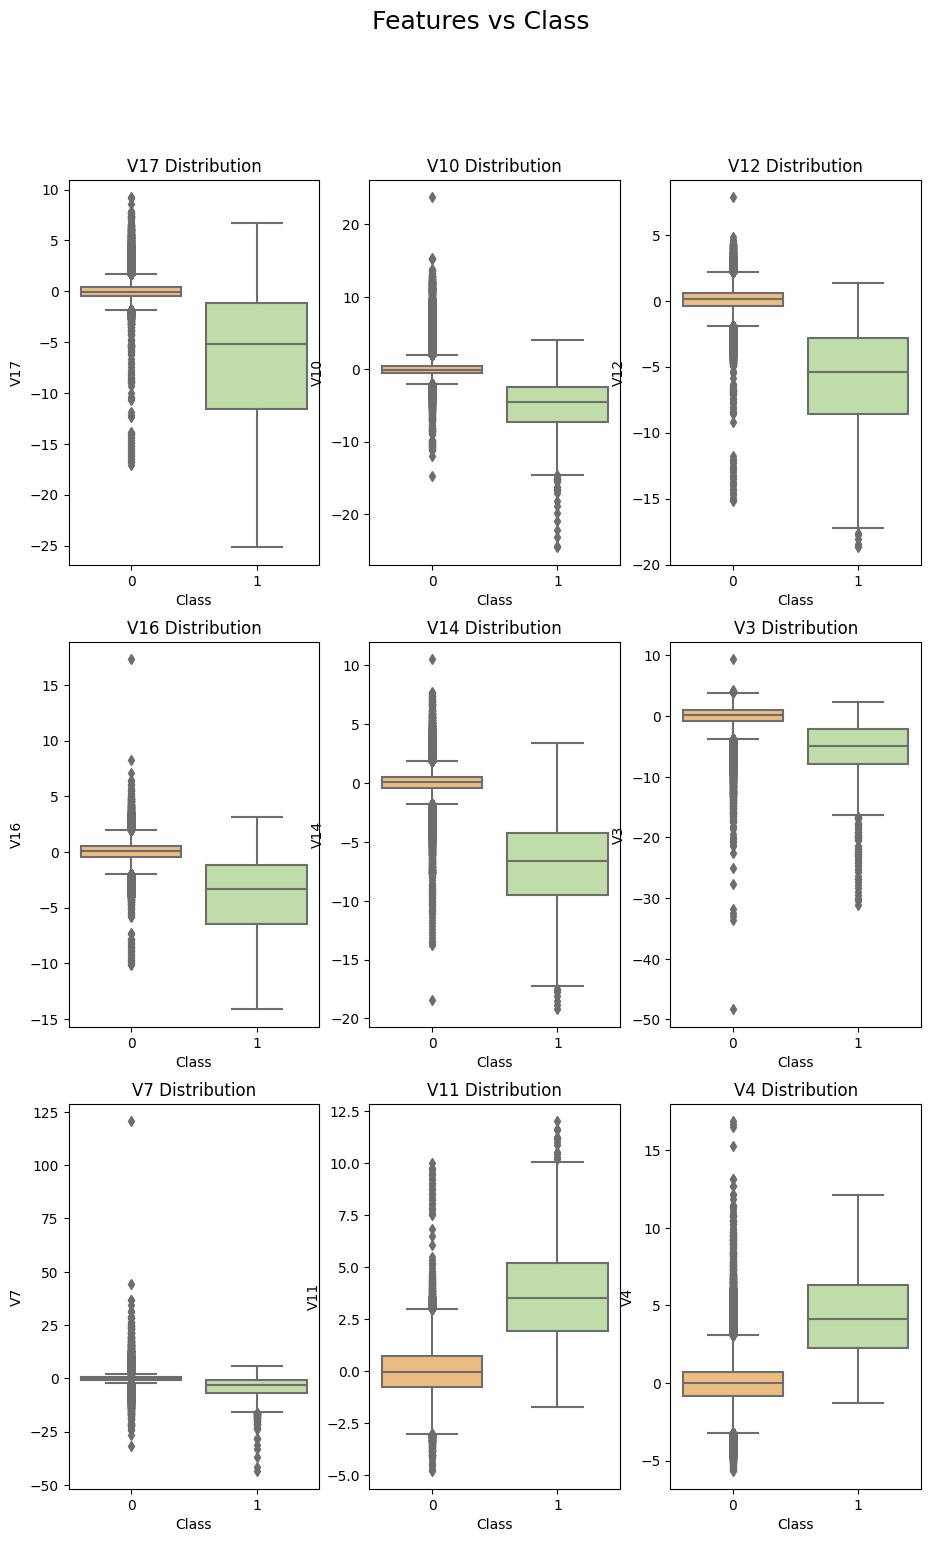

In [15]:
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (11, 17))
fig.suptitle("Features vs Class\n", size = 18)

sns.boxplot(ax = axes[0, 0], data = df, x = "Class", y = "V17", palette = "Spectral")
axes[0, 0].set_title("V17 Distribution");

sns.boxplot(ax = axes[0, 1], data = df, x = "Class", y = "V10", palette = "Spectral")
axes[0, 1].set_title("V10 Distribution");

sns.boxplot(ax = axes[0, 2], data = df, x = "Class", y = "V12", palette = "Spectral")
axes[0, 2].set_title("V12 Distribution");

sns.boxplot(ax = axes[1, 0], data = df, x = "Class", y = "V16", palette = "Spectral")
axes[1, 0].set_title("V16 Distribution");

sns.boxplot(ax = axes[1, 1], data = df, x = "Class", y = "V14", palette = "Spectral")
axes[1, 1].set_title("V14 Distribution");

sns.boxplot(ax = axes[1, 2], data = df, x = "Class", y = "V3", palette = "Spectral")
axes[1, 2].set_title("V3 Distribution");

sns.boxplot(ax = axes[2, 0], data = df, x = "Class", y = "V7", palette = "Spectral")
axes[2, 0].set_title("V7 Distribution");

sns.boxplot(ax = axes[2, 1], data = df, x = "Class", y = "V11", palette = "Spectral")
axes[2, 1].set_title("V11 Distribution");

sns.boxplot(ax = axes[2, 2], data = df, x = "Class", y = "V4", palette = "Spectral")
axes[2, 2].set_title("V4 Distribution");

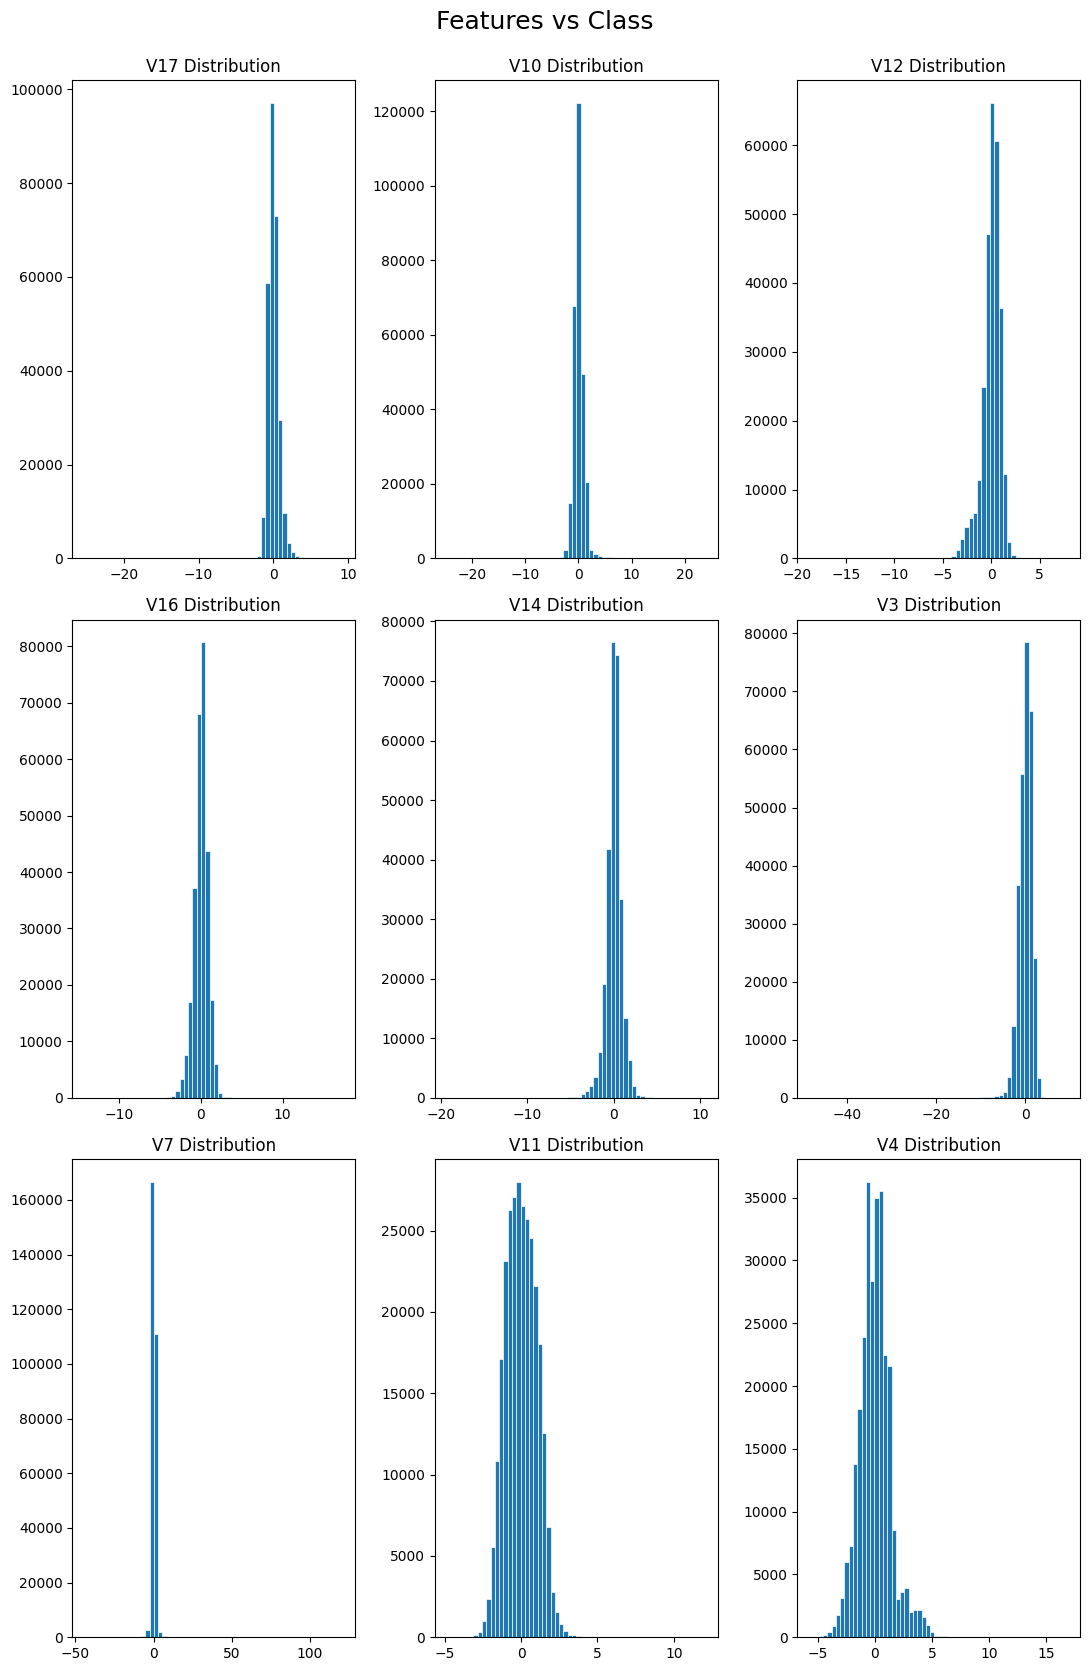

In [16]:
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (11, 17))
fig.suptitle("Features vs Class\n", size = 18)

axes[0, 0].hist(df["V17"], bins = 60, linewidth = 0.5, edgecolor = "white")
axes[0, 0].set_title("V17 Distribution");

axes[0, 1].hist(df["V10"], bins = 60, linewidth = 0.5, edgecolor = "white")
axes[0, 1].set_title("V10 Distribution");

axes[0, 2].hist(df["V12"], bins = 60, linewidth = 0.5, edgecolor = "white")
axes[0, 2].set_title("V12 Distribution");

axes[1, 0].hist(df["V16"], bins = 60, linewidth = 0.5, edgecolor = "white")
axes[1, 0].set_title("V16 Distribution");

axes[1, 1].hist(df["V14"], bins = 60, linewidth = 0.5, edgecolor = "white")
axes[1, 1].set_title("V14 Distribution");

axes[1, 2].hist(df["V3"], bins = 60, linewidth = 0.5, edgecolor = "white")
axes[1, 2].set_title("V3 Distribution");

axes[2, 0].hist(df["V7"], bins = 60, linewidth = 0.5, edgecolor = "white")
axes[2, 0].set_title("V7 Distribution");

axes[2, 1].hist(df["V11"], bins = 60, linewidth = 0.5, edgecolor = "white")
axes[2, 1].set_title("V11 Distribution");

axes[2, 2].hist(df["V4"], bins = 60, linewidth = 0.5, edgecolor = "white")
axes[2, 2].set_title("V4 Distribution");

plt.tight_layout()

# 1. Tukey's IQR Method

In [17]:
def IQR_method (df,n,features):
    """
    Takes a dataframe and returns an index list corresponding to the observations 
    containing more than n outliers according to the Tukey IQR method.
    """
    outlier_list = []
    
    for column in features:
                
        # 1st quartile (25%)
        Q1 = np.percentile(df[column], 25)
        # 3rd quartile (75%)
        Q3 = np.percentile(df[column],75)
        
        # Interquartile range (IQR)
        IQR = Q3 - Q1
        
        # outlier step
        outlier_step = 1.5 * IQR
        
        # Determining a list of indices of outliers
        outlier_list_column = df[(df[column] < Q1 - outlier_step) | (df[column] > Q3 + outlier_step )].index
        
        # appending the list of outliers 
        outlier_list.extend(outlier_list_column)
        
    # selecting observations containing more than x outliers
    outlier_list = Counter(outlier_list)        
    multiple_outliers = list( k for k, v in outlier_list.items() if v > n )
    
    # Calculate the number of records below and above lower and above bound value respectively
    df1 = df[df[column] < Q1 - outlier_step]
    df2 = df[df[column] > Q3 + outlier_step]
    
    print('Total number of outliers is:', df1.shape[0]+df2.shape[0])
    
    return multiple_outliers

## Detecting Outliers

In [18]:
Outliers_IQR = IQR_method(df, 1, feature_list)
# Printing the first 100 outliers
print(Outliers_IQR[:100])

Total number of outliers is: 31685
[18, 85, 140, 146, 164, 174, 210, 290, 401, 811, 827, 1158, 1608, 1632, 1753, 1813, 1911, 1922, 2059, 2178, 2186, 2234, 2278, 2301, 2386, 2464, 2475, 2589, 2611, 2682, 2791, 2792, 2897, 2951, 2954, 2956, 2957, 2963, 3278, 3282, 3443, 3505, 3509, 3547, 3554, 3555, 3602, 4235, 4415, 4608, 4675, 4740, 4776, 4810, 4895, 4926, 4950, 5139, 5257, 5296, 5306, 5371, 5392, 5401, 5425, 5504, 5512, 5526, 5534, 5535, 5615, 5652, 5676, 5715, 5733, 5797, 5827, 5888, 6108, 6223, 6286, 6300, 6305, 6306, 6330, 6341, 6410, 6467, 6501, 6547, 6590, 6624, 6692, 6727, 6783, 6788, 6802, 6812, 6882, 6905]


## Dropping Outliers

In [19]:
df_out = df.drop(Outliers_IQR, axis = 0).reset_index(drop=True)
df_out.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,...,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,...,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,...,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
3,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,...,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0
4,-0.426,0.961,1.141,-0.168,0.421,-0.030,0.476,0.260,-0.569,-0.371,...,-0.208,-0.560,-0.026,-0.371,-0.233,0.106,0.254,0.081,3.670,0


## Visualizations After Dropping Outliers

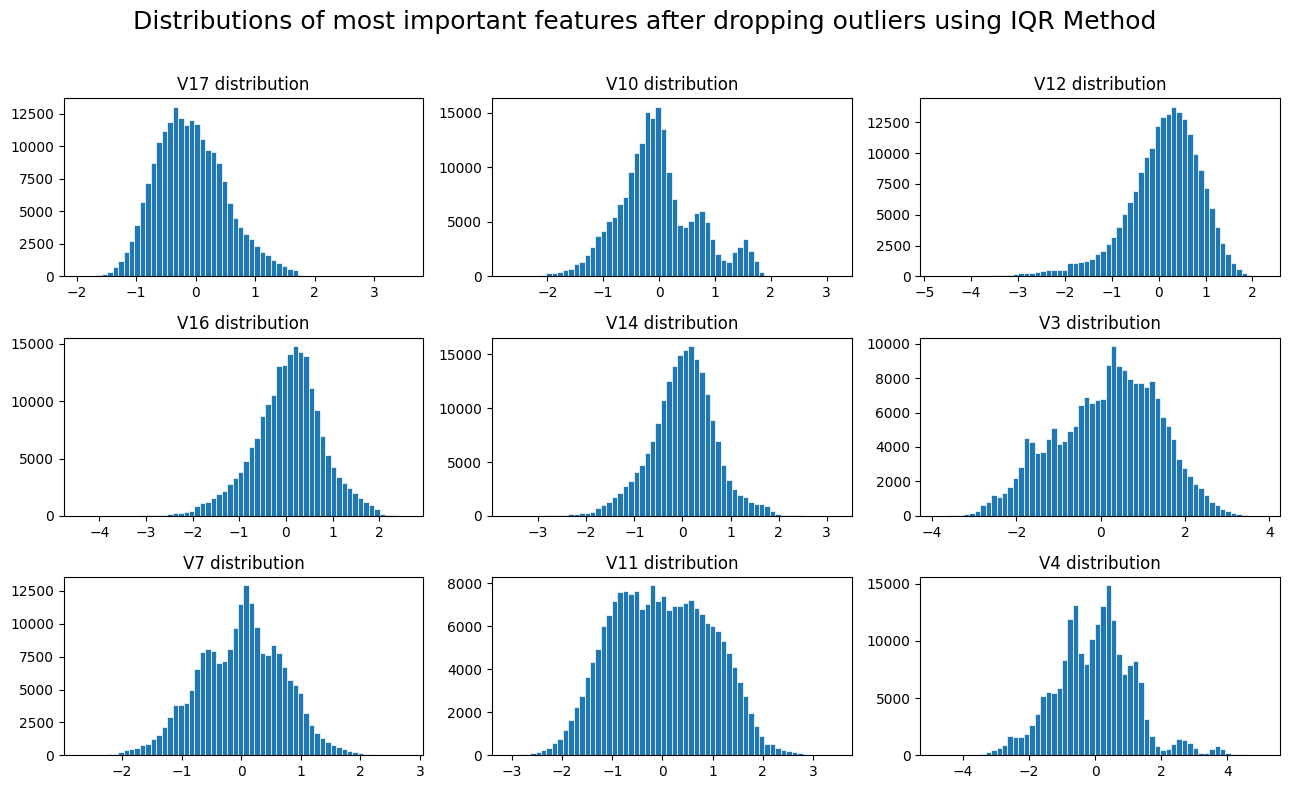

In [20]:
# Checking distributions of most important features after dropping outliers

fig, axes = plt.subplots(nrows=3, ncols=3,figsize=(13,8))
fig.suptitle('Distributions of most important features after dropping outliers using IQR Method\n', size = 18)

axes[0,0].hist(df_out['V17'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,0].set_title("V17 distribution");

axes[0,1].hist(df_out['V10'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,1].set_title("V10 distribution");

axes[0,2].hist(df_out['V12'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,2].set_title("V12 distribution");

axes[1,0].hist(df_out['V16'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,0].set_title("V16 distribution");

axes[1,1].hist(df_out['V14'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,1].set_title("V14 distribution");

axes[1,2].hist(df_out['V3'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,2].set_title("V3 distribution");

axes[2,0].hist(df_out['V7'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,0].set_title("V7 distribution");

axes[2,1].hist(df_out['V11'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,1].set_title("V11 distribution");

axes[2,2].hist(df_out['V4'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,2].set_title("V4 distribution");

plt.tight_layout()

# 2. Standard Deviation Method

In [21]:
def StDev_method (df,n,features):
    """
    Takes a dataframe df of features and returns an index list corresponding to the observations 
    containing more than n outliers according to the standard deviation method.
    """
    outlier_indices = []
    
    for column in features:
        # calculate the mean and standard deviation of the data frame
        data_mean = df[column].mean()
        data_std = df[column].std()
        
        # calculate the cutoff value
        cut_off = data_std * 3
        
        # Determining a list of indices of outliers for feature column        
        outlier_list_column = df[(df[column] < data_mean - cut_off) | (df[column] > data_mean + cut_off)].index
        
        # appending the found outlier indices for column to the list of outlier indices 
        outlier_indices.extend(outlier_list_column)
        
    # selecting observations containing more than x outliers
    outlier_indices = Counter(outlier_indices)        
    multiple_outliers = list( k for k, v in outlier_indices.items() if v > n )
    
    # Calculate the number of records below and above lower and above bound value respectively
    df1 = df[df[column] > data_mean + cut_off]
    df2 = df[df[column] < data_mean - cut_off]
    print('Total number of outliers is:', df1.shape[0]+ df2.shape[0])
    
    return multiple_outliers   

## Detecting Outliers

In [22]:
Outliers_StDev = StDev_method(df,1,feature_list)
# Printing the first 100 outliers
print(Outliers_StDev[:100])

Total number of outliers is: 4063
[164, 290, 1158, 1632, 2178, 2464, 2682, 2792, 2957, 2963, 3509, 3554, 4235, 4608, 4810, 5296, 5371, 5425, 5526, 5534, 5535, 5715, 5797, 5888, 6223, 6467, 6501, 6624, 6727, 6783, 6812, 6905, 6958, 6969, 7080, 7081, 7090, 7104, 7144, 7178, 7246, 7255, 7277, 7348, 7420, 7485, 7522, 7523, 7560, 7578, 7580, 7616, 7617, 7743, 7744, 8447, 8487, 8488, 8572, 8610, 8683, 8820, 8855, 8973, 9106, 9119, 9545, 9895, 10115, 10131, 10460, 10483, 10515, 10535, 10567, 10573, 10582, 10584, 10607, 10690, 10801, 10804, 10891, 10897, 10900, 10913, 11033, 11222, 11300, 11343, 11364, 11465, 11681, 11710, 11841, 11842, 11880, 11891, 11956, 12021]


## Dropping Outliers

In [23]:
df_out2 = df.drop(Outliers_StDev, axis = 0).reset_index(drop = True)
df_out2.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,...,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,...,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,...,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0
3,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,...,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
4,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,...,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0


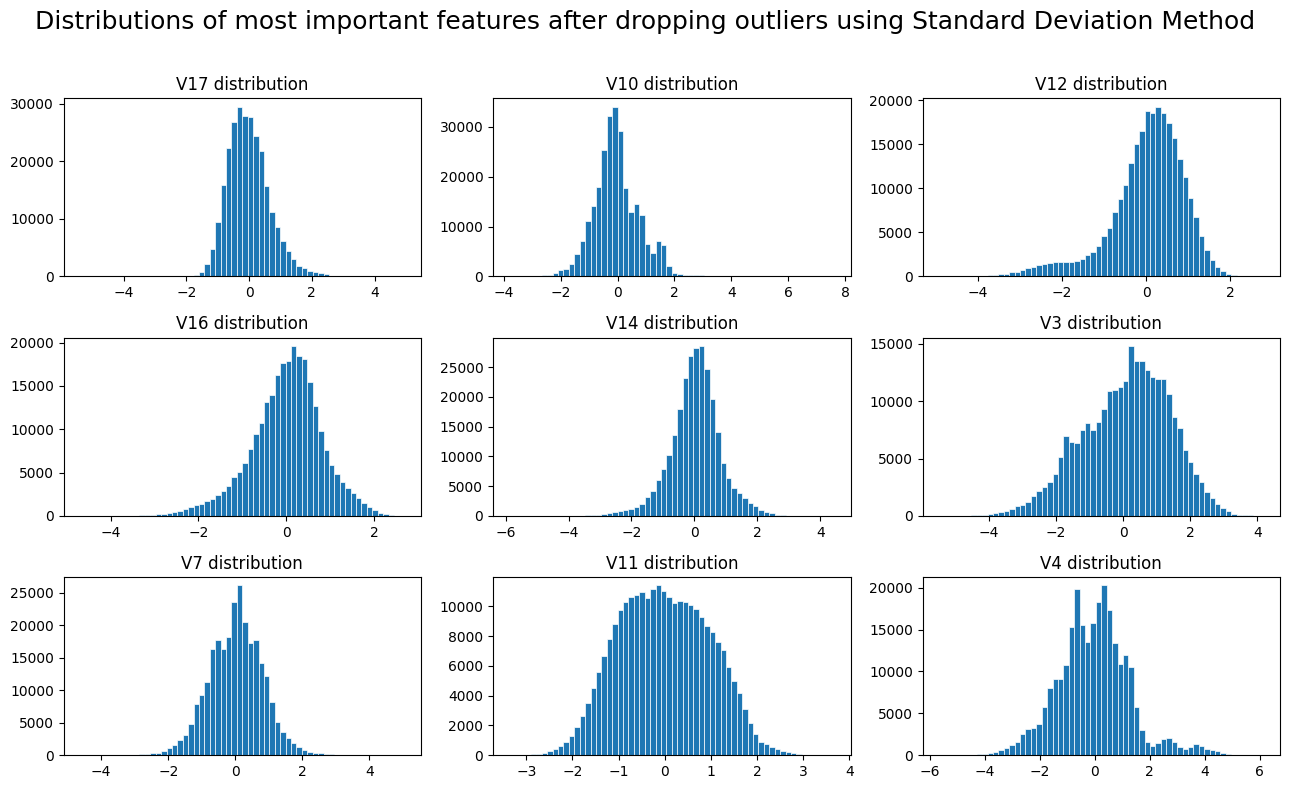

In [24]:
# Checking distributions of most important features after dropping outliers

fig, axes = plt.subplots(nrows=3, ncols=3,figsize=(13,8))
fig.suptitle('Distributions of most important features after dropping outliers using Standard Deviation Method\n', size = 18)


axes[0,0].hist(df_out2['V17'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,0].set_title("V17 distribution");

axes[0,1].hist(df_out2['V10'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,1].set_title("V10 distribution");

axes[0,2].hist(df_out2['V12'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,2].set_title("V12 distribution");

axes[1,0].hist(df_out2['V16'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,0].set_title("V16 distribution");

axes[1,1].hist(df_out2['V14'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,1].set_title("V14 distribution");

axes[1,2].hist(df_out2['V3'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,2].set_title("V3 distribution");

axes[2,0].hist(df_out2['V7'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,0].set_title("V7 distribution");

axes[2,1].hist(df_out2['V11'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,1].set_title("V11 distribution");

axes[2,2].hist(df_out2['V4'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,2].set_title("V4 distribution");

plt.tight_layout()

# 3. Z-score Method

In [25]:
def z_score_method (df,n,features):
    """
    Takes a dataframe df of features and returns an index list corresponding to the observations 
    containing more than n outliers according to the z-score method.
    """
    outlier_list = []
    
    for column in features:
        # calculate the mean and standard deviation of the data frame
        data_mean = df[column].mean()
        data_std = df[column].std()
        threshold = 3
        
        z_score = abs( (df[column] - data_mean)/data_std )
        
        # Determining a list of indices of outliers for feature column        
        outlier_list_column =  df[z_score > threshold].index
        
        # appending the found outlier indices for column to the list of outlier indices 
        outlier_list.extend(outlier_list_column)
        
    # selecting observations containing more than x outliers
    outlier_list = Counter(outlier_list)        
    multiple_outliers = list( k for k, v in outlier_list.items() if v > n )
    
    # Calculate the number of outlier records
    df1 = df[z_score > threshold]
    print('Total number of outliers is:', df1.shape[0])
    
    return multiple_outliers

## Detecting Outliers

In [26]:
Outliers_z_score = z_score_method(df, 1, feature_list)
#Print the first 100 outliers
print(Outliers_z_score[:100])

Total number of outliers is: 4063
[164, 290, 1158, 1632, 2178, 2464, 2682, 2792, 2957, 2963, 3509, 3554, 4235, 4608, 4810, 5296, 5371, 5425, 5526, 5534, 5535, 5715, 5797, 5888, 6223, 6467, 6501, 6624, 6727, 6783, 6812, 6905, 6958, 6969, 7080, 7081, 7090, 7104, 7144, 7178, 7246, 7255, 7277, 7348, 7420, 7485, 7522, 7523, 7560, 7578, 7580, 7616, 7617, 7743, 7744, 8447, 8487, 8488, 8572, 8610, 8683, 8820, 8855, 8973, 9106, 9119, 9545, 9895, 10115, 10131, 10460, 10483, 10515, 10535, 10567, 10573, 10582, 10584, 10607, 10690, 10801, 10804, 10891, 10897, 10900, 10913, 11033, 11222, 11300, 11343, 11364, 11465, 11681, 11710, 11841, 11842, 11880, 11891, 11956, 12021]


## Dropping Outliers

In [27]:
df_out3 = df.drop(Outliers_z_score, axis = 0).reset_index(drop = True)
df_out3.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,...,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,...,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,...,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0
3,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,...,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
4,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,...,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0


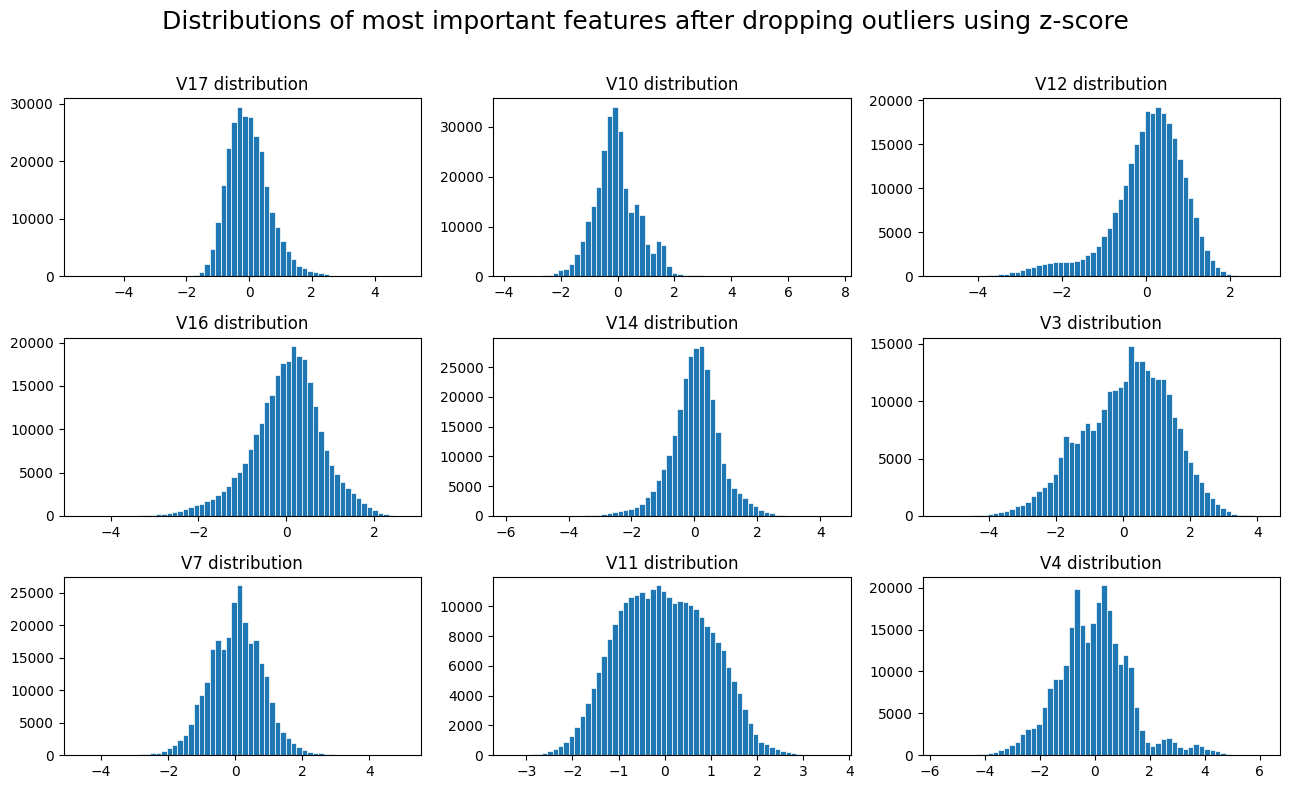

In [28]:
# Checking distributions of most important features after dropping outliers

fig, axes = plt.subplots(nrows=3, ncols=3,figsize=(13,8))
fig.suptitle('Distributions of most important features after dropping outliers using z-score\n', size = 18)

axes[0,0].hist(df_out3['V17'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,0].set_title("V17 distribution");

axes[0,1].hist(df_out3['V10'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,1].set_title("V10 distribution");

axes[0,2].hist(df_out3['V12'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,2].set_title("V12 distribution");

axes[1,0].hist(df_out3['V16'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,0].set_title("V16 distribution");

axes[1,1].hist(df_out3['V14'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,1].set_title("V14 distribution");

axes[1,2].hist(df_out3['V3'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,2].set_title("V3 distribution");

axes[2,0].hist(df_out3['V7'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,0].set_title("V7 distribution");

axes[2,1].hist(df_out3['V11'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,1].set_title("V11 distribution");

axes[2,2].hist(df_out3['V4'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,2].set_title("V4 distribution");

plt.tight_layout()

# 4. Modified Z-score

In [29]:
from scipy.stats import median_abs_deviation

def z_scoremod_method (df,n,features):
    """
    Takes a dataframe df of features and returns an index list corresponding to the observations 
    containing more than n outliers according to the z-score modified method.
    """
    outlier_list = []
    
    for column in features:
        # calculate the mean and standard deviation of the data frame
        data_mean = df[column].mean()
        data_std = df[column].std()
        threshold = 3
        MAD = median_abs_deviation
        
        mod_z_score = abs(0.6745*(df[column] - data_mean)/MAD(df[column]) )
                
        # Determining a list of indices of outliers for feature column        
        outlier_list_column =  df[mod_z_score >threshold].index
        
        # appending the found outlier indices for column to the list of outlier indices 
        outlier_list.extend(outlier_list_column)
        
    # selecting observations containing more than x outliers
    outlier_list = Counter(outlier_list)        
    multiple_outliers = list( k for k, v in outlier_list.items() if v > n )
    
    # Calculate the number of outlier records
    df1 = df[mod_z_score >threshold]
    print('Total number of outliers is:', df1.shape[0])
    
    return multiple_outliers

In [30]:
# detecting outliers
Outliers_z_score = z_scoremod_method(df,1,feature_list)

Total number of outliers is: 32976


In [31]:
df_out4 = df.drop(Outliers_z_score, axis = 0).reset_index(drop=True)

In [32]:
df_out4.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,...,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,...,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,...,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
3,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,...,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0
4,-0.426,0.961,1.141,-0.168,0.421,-0.030,0.476,0.260,-0.569,-0.371,...,-0.208,-0.560,-0.026,-0.371,-0.233,0.106,0.254,0.081,3.670,0


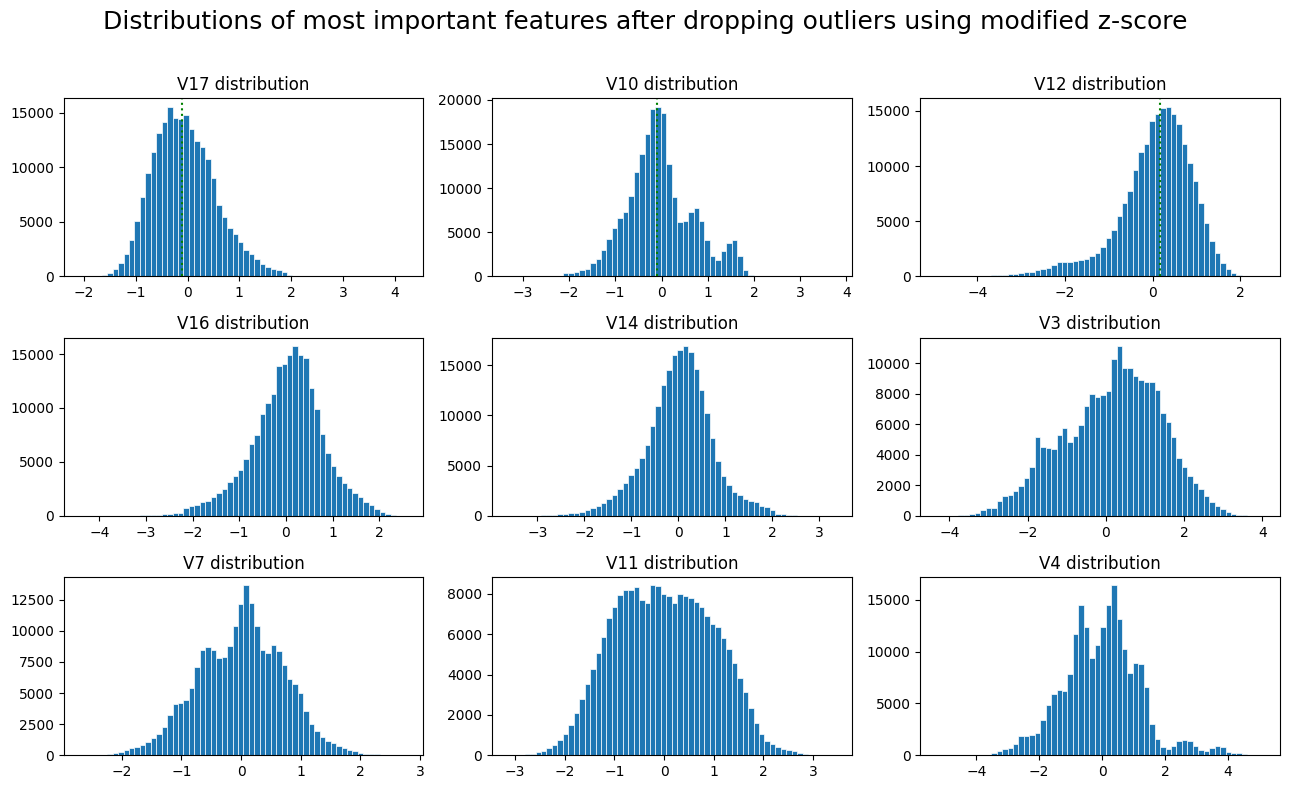

In [33]:
# Checking distributions of most important features after dropping outliers

fig, axes = plt.subplots(nrows=3, ncols=3,figsize=(13,8))
fig.suptitle('Distributions of most important features after dropping outliers using modified z-score\n', size = 18)

axes[0,0].hist(df_out4['V17'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,0].axvline(np.median(df_out4['V17']), ls=':', c='g', label="Median")
axes[0,0].set_title("V17 distribution");

axes[0,1].hist(df_out4['V10'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,1].axvline(np.median(df_out4['V10']), ls=':', c='g', label="Median")
axes[0,1].set_title("V10 distribution");

axes[0,2].hist(df_out4['V12'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,2].axvline(np.median(df_out4['V12']), ls=':', c='g', label="Median")
axes[0,2].set_title("V12 distribution");

axes[1,0].hist(df_out4['V16'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,0].set_title("V16 distribution");

axes[1,1].hist(df_out4['V14'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,1].set_title("V14 distribution");

axes[1,2].hist(df_out4['V3'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,2].set_title("V3 distribution");

axes[2,0].hist(df_out4['V7'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,0].set_title("V7 distribution");

axes[2,1].hist(df_out4['V11'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,1].set_title("V11 distribution");

axes[2,2].hist(df_out4['V4'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,2].set_title("V4 distribution");

plt.tight_layout()

# 5. Isolation Forest

In [34]:
from sklearn.ensemble import IsolationForest

df5 = df.copy()
df5 = df5.drop(['Class'], axis=1)

In [35]:
model=IsolationForest(n_estimators=150, max_samples='auto', contamination=float(0.1), max_features=1.0)
model.fit(df5)

IsolationForest(contamination=0.1, n_estimators=150)

In [36]:
scores=model.decision_function(df5)
anomaly=model.predict(df5)

df5['scores']=scores
df5['anomaly']=anomaly

df5.head(10)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,scores,anomaly
0,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,...,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0.075,1
1,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,...,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0.099,1
2,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,...,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,-0.011,-1
3,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,...,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0.047,1
4,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,...,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0.061,1
5,-0.426,0.961,1.141,-0.168,0.421,-0.030,0.476,0.260,-0.569,-0.371,...,-0.560,-0.026,-0.371,-0.233,0.106,0.254,0.081,3.670,0.096,1
6,1.230,0.141,0.045,1.203,0.192,0.273,-0.005,0.081,0.465,-0.099,...,-0.271,-0.154,-0.780,0.750,-0.257,0.035,0.005,4.990,0.084,1
7,-0.644,1.418,1.074,-0.492,0.949,0.428,1.121,-3.808,0.615,1.249,...,-1.015,0.058,-0.650,-0.415,-0.052,-1.207,-1.085,40.800,-0.027,-1
8,-0.894,0.286,-0.113,-0.272,2.670,3.722,0.370,0.851,-0.392,-0.410,...,-0.268,-0.204,1.012,0.373,-0.384,0.012,0.142,93.200,0.063,1
9,-0.338,1.120,1.044,-0.222,0.499,-0.247,0.652,0.070,-0.737,-0.367,...,-0.634,-0.121,-0.385,-0.070,0.094,0.246,0.083,3.680,0.090,1


In [37]:
anomaly = df5.loc[df5['anomaly']==-1]
anomaly_index = list(anomaly.index)
print('Total number of outliers is:', len(anomaly))

Total number of outliers is: 28373


In [38]:
df5[df5['anomaly']==-1].head(10)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,scores,anomaly
2,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,...,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,-0.011,-1
7,-0.644,1.418,1.074,-0.492,0.949,0.428,1.121,-3.808,0.615,1.249,...,-1.015,0.058,-0.650,-0.415,-0.052,-1.207,-1.085,40.800,-0.027,-1
18,-5.401,-5.450,1.186,1.736,3.049,-1.763,-1.560,0.161,1.233,0.345,...,0.984,2.459,0.042,-0.482,-0.621,0.392,0.950,46.800,-0.037,-1
51,-1.005,-0.986,-0.038,3.710,-6.632,5.122,4.372,-2.007,-0.279,-0.231,...,-0.382,0.970,0.019,0.571,0.333,0.857,-0.076,1402.950,-0.055,-1
69,-1.923,-0.870,2.320,1.989,0.417,-0.380,0.472,-0.557,-0.649,1.411,...,-0.779,1.086,0.519,-0.364,3.066,-0.589,-0.396,35.000,-0.005,-1
82,-3.005,2.600,1.484,-2.418,0.306,-0.825,2.065,-1.829,4.009,6.052,...,-0.181,-0.164,0.516,0.136,0.460,-0.251,-1.106,1.460,-0.091,-1
83,-1.199,-1.474,1.840,-4.516,0.328,-0.174,0.960,-1.026,1.700,-0.079,...,0.335,-0.365,-0.310,-0.303,-1.244,-1.123,-0.734,89.170,-0.056,-1
85,-4.575,-4.429,3.403,0.904,3.002,-0.491,-2.705,0.666,1.922,-0.614,...,0.853,-0.972,-0.115,0.408,-0.305,0.548,-0.456,200.010,-0.061,-1
89,-0.773,-4.146,-0.932,0.027,-1.698,0.460,0.737,-0.314,-0.843,0.017,...,0.026,-1.135,-0.655,0.098,-0.209,-0.172,0.208,1142.020,-0.021,-1
102,0.299,2.143,-1.542,1.561,0.938,-2.146,1.406,-0.778,0.329,0.127,...,-0.000,0.092,0.586,-0.397,-0.481,0.251,-0.242,0.780,-0.004,-1


In [39]:
# dropping outliers
df_out5 = df5.drop(anomaly_index, axis = 0).reset_index(drop=True)

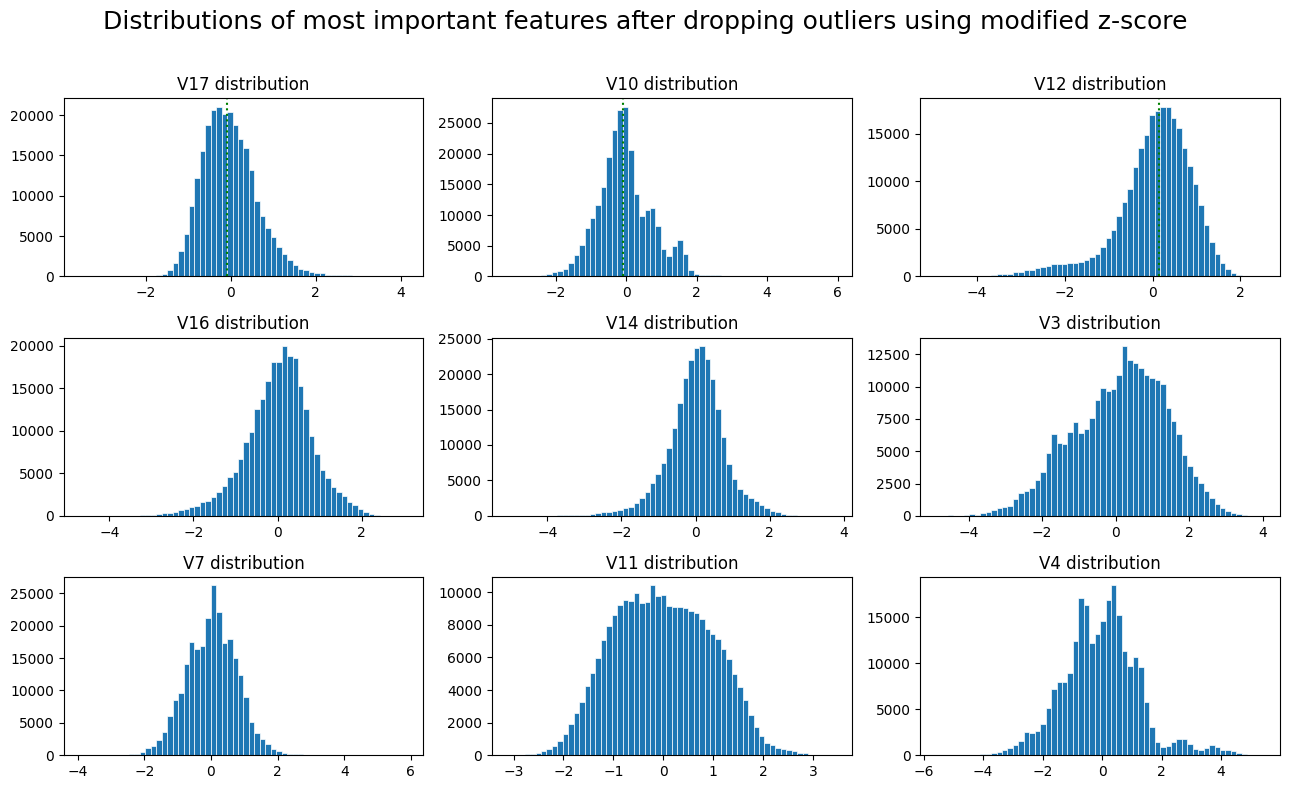

In [40]:
# Checking distributions of most important features after dropping outliers

fig, axes = plt.subplots(nrows=3, ncols=3,figsize=(13,8))
fig.suptitle('Distributions of most important features after dropping outliers using modified z-score\n', size = 18)

axes[0,0].hist(df_out5['V17'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,0].axvline(np.median(df_out5['V17']), ls=':', c='g', label="Median")
axes[0,0].set_title("V17 distribution");

axes[0,1].hist(df_out5['V10'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,1].axvline(np.median(df_out5['V10']), ls=':', c='g', label="Median")
axes[0,1].set_title("V10 distribution");

axes[0,2].hist(df_out5['V12'], bins=60, linewidth=0.5, edgecolor="white")
axes[0,2].axvline(np.median(df_out5['V12']), ls=':', c='g', label="Median")
axes[0,2].set_title("V12 distribution");

axes[1,0].hist(df_out5['V16'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,0].set_title("V16 distribution");

axes[1,1].hist(df_out5['V14'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,1].set_title("V14 distribution");

axes[1,2].hist(df_out5['V3'], bins=60, linewidth=0.5, edgecolor="white")
axes[1,2].set_title("V3 distribution");

axes[2,0].hist(df_out5['V7'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,0].set_title("V7 distribution");

axes[2,1].hist(df_out5['V11'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,1].set_title("V11 distribution");

axes[2,2].hist(df_out5['V4'], bins=60, linewidth=0.5, edgecolor="white")
axes[2,2].set_title("V4 distribution");

plt.tight_layout()

# 6. DBSCAN - Density-Based Spatial Clustering of Applications with Noise

In [41]:
df6 = df.copy()
df6 = df6.drop(['Class'], axis=1)

In [42]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# scale data first
X = StandardScaler().fit_transform(df6.values)

db = DBSCAN(eps=3.0, min_samples=10).fit(X)
labels = db.labels_

In [43]:
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
print('The number of clusters in dataset is:', n_clusters_)

The number of clusters in dataset is: 39


In [44]:
pd.Series(labels).value_counts()

 0     196273
 1      32446
-1      20325
 9      14841
 2      12254
 5       2046
 7       1405
 12      1168
 10       823
 3        329
 26       287
 13       214
 17       212
 14       206
 11       170
 18       166
 19        81
 4         80
 31        48
 22        38
 21        32
 24        32
 32        24
 15        21
 30        20
 16        19
 27        18
 29        17
 28        16
 23        15
 33        14
 35        12
 37        10
 38        10
 25        10
 6         10
 36        10
 8          9
 20         8
 34         7
Name: count, dtype: int64

# Sincerely, Mr. Eslam Fouad.